In [1]:
# Put import statements here
import os
# hide tensorflow info/warning logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import sys
import subprocess
from pathlib import Path


# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
from src.util.config import config, PROJECT_ROOT
import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer


I0000 00:00:1789185204.128900    4909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789185205.778081    4909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# Run pytest setup tests to verify the environment/hardware is good to go
#subprocess.run(
#    [sys.executable, "-m", "pytest", "-q", "test/test_setup.py"],
#    check=False,
#)

In [3]:
# Determine the project's data repo location
DATA_DIR= PROJECT_ROOT / "data"


In [4]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / config.data.PlantExpertVQA.data_path
plant_expert_vqa_path= DATA_DIR / "PlantExpertVQA"
train_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.train_file
test_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.test_file
validation_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.validation_file


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

20:53:29 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/home/chris/capstone/PlantQA/src/data_preprocessing/text_preprocessing.py:27: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


20:53:30 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
20:53:30 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [5]:
PEVQA_text_columns= general_util.parse_list_from_string(config.data.PlantExpertVQA.text_columns)
PEVQA_columns_to_remove= general_util.parse_list_from_string(config.data.PlantExpertVQA.columns_to_remove)
PEVQA_na_fill= vars(config.data.PlantExpertVQA.na_fill)

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              535881 non-null  object
 1   image_id           535881 non-null  object
 2   image_path         535881 non-null  object
 3   crop               535881 non-null  object
 4   disease            535881 non-null  object
 5   category           535881 non-null  object
 6   severity           535881 non-null  object
 7   question_text      535881 non-null  object
 8   answer             535881 non-null  object
 9   answer_type        535881 non-null  object
 10  question_category  535881 non-null  object
 11  cognitive_level    535881 non-null  object
dtypes: object(12)
memory usage: 49.1+ MB
20:53:44 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



20:53:45 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                      

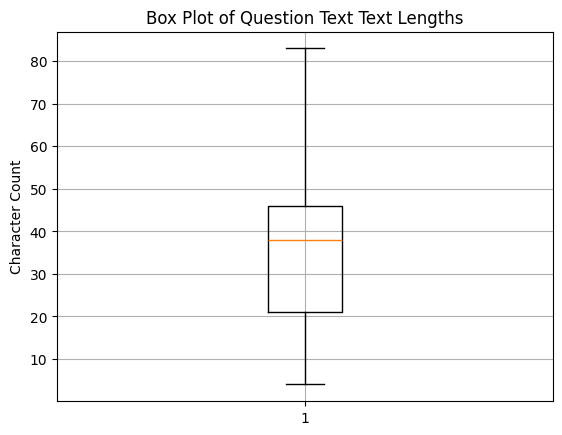

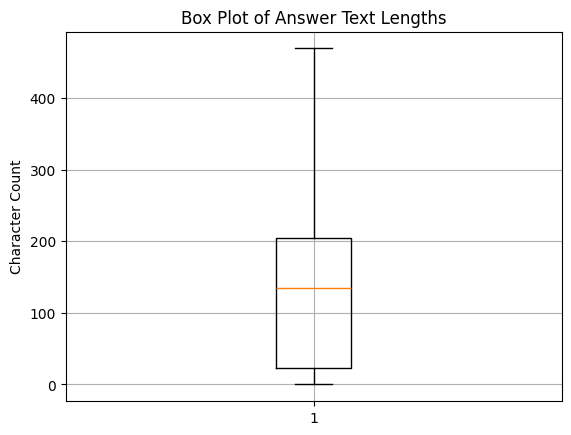







20:53:45 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




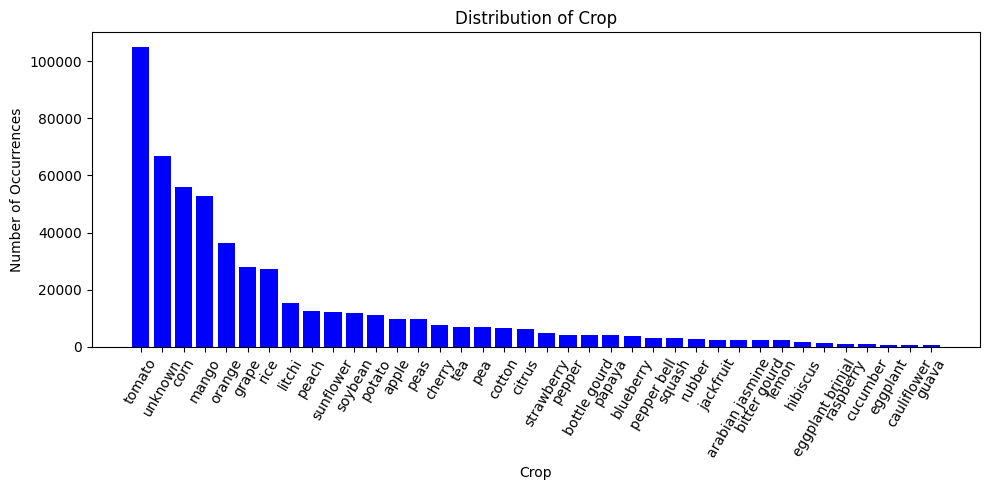

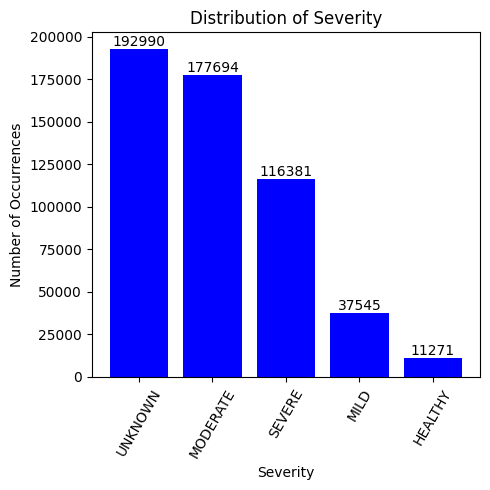

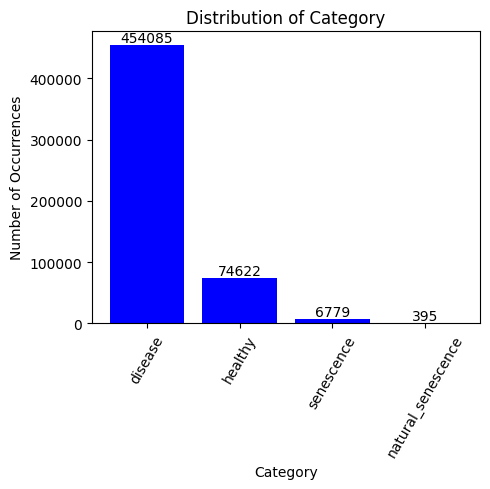

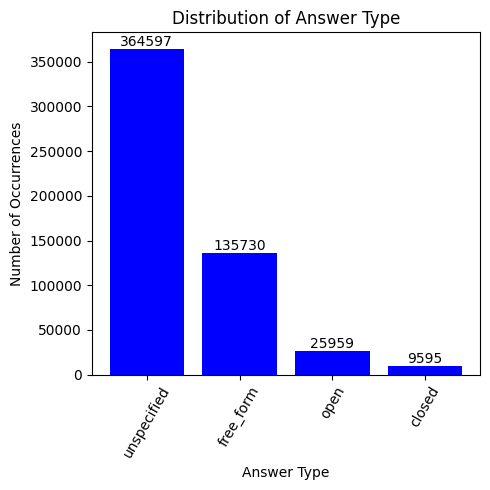

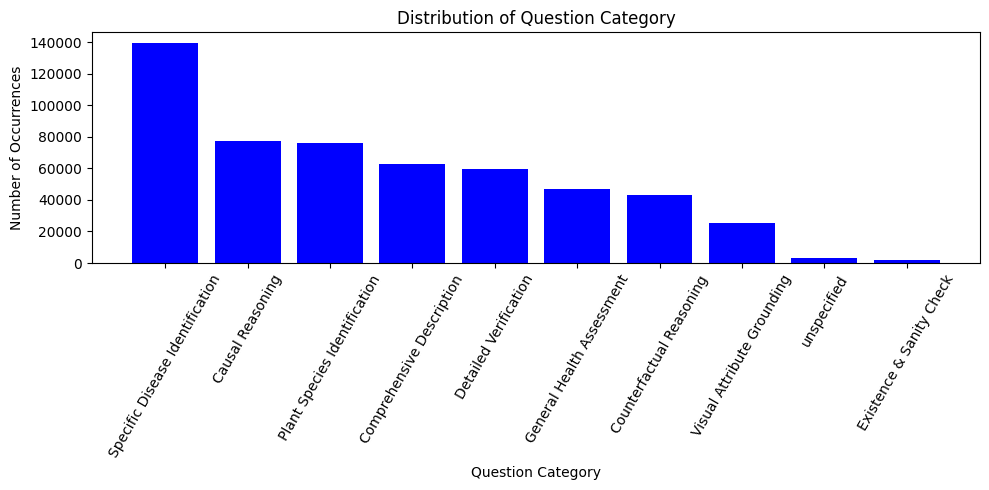







20:53:46 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




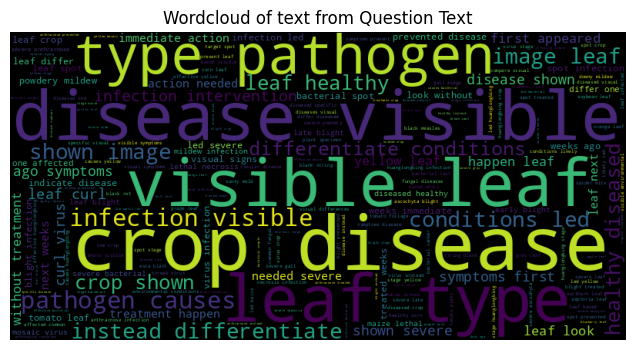

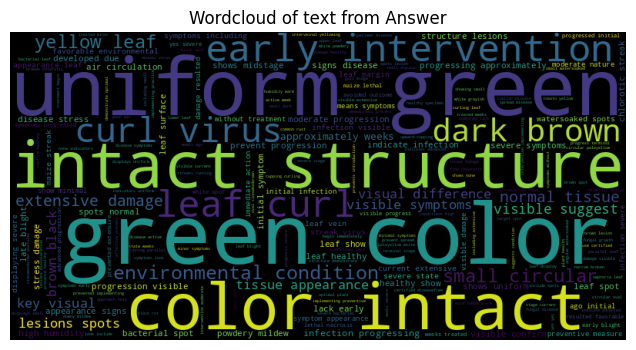







20:54:00 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




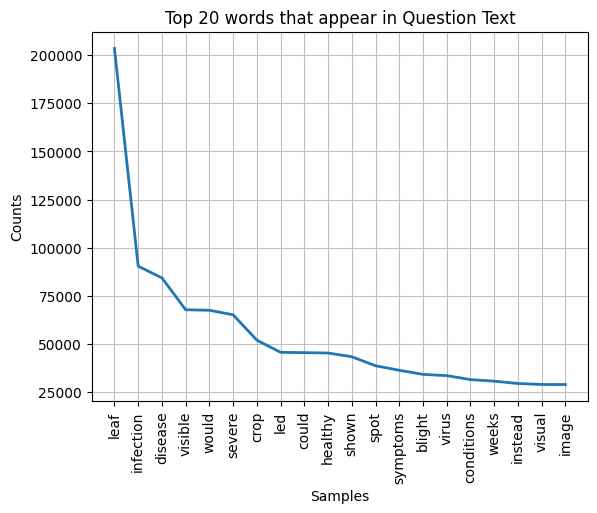

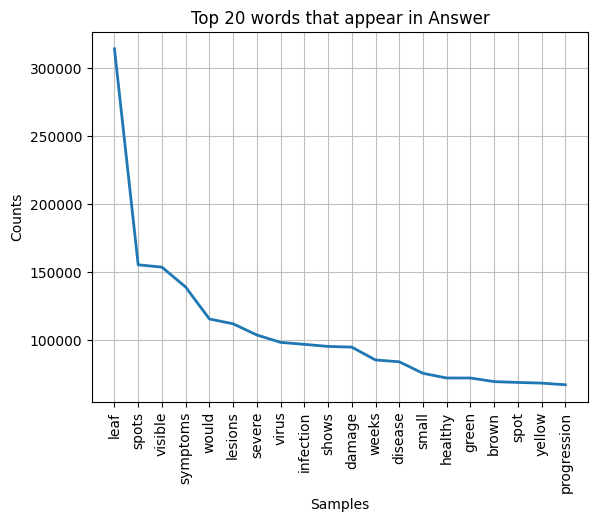

In [6]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    PEVQA_text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [7]:
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

encoding= tokenizer.encode_text("hello", None)

Logger.info(encoding)
Logger.info(type(encoding))

encoding= tokenizer.encode_text(["hello"], None)

Logger.info(encoding)
Logger.info(type(encoding))

encoding= tokenizer.encode_text(["hello", "goodbye it was nice to meet you"], None)

Logger.info(encoding)
Logger.info(type(encoding))

20:54:04 [INFO    ]: {'input_ids': [[101, 7592, 102]], 'token_type_ids': [[0, 0, 0]], 'attention_mask': [[1, 1, 1]]}
20:54:04 [INFO    ]: <class 'transformers.tokenization_utils_base.BatchEncoding'>
20:54:04 [INFO    ]: {'input_ids': [[101, 7592, 102]], 'token_type_ids': [[0, 0, 0]], 'attention_mask': [[1, 1, 1]]}
20:54:04 [INFO    ]: <class 'transformers.tokenization_utils_base.BatchEncoding'>
20:54:04 [INFO    ]: {'input_ids': [[101, 7592, 102, 0, 0, 0, 0, 0, 0], [101, 9119, 2009, 2001, 3835, 2000, 3113, 2017, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1]]}
20:54:04 [INFO    ]: <class 'transformers.tokenization_utils_base.BatchEncoding'>


In [ ]:
# Adding on macbook - will need to retest on workstation later tonight due to GPU acceleration
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"
traits = ["crop", "disease", "category", "severity"]

classes = {}
for t in traits:
    names = sorted(plant_expert_vqa_TRAIN[t].unique())  # adds names of plants
    classes[t] = names + ["unknown"]  # adds unknown species

train_ds = VisualModel.make_dataset(plant_expert_vqa_TRAIN, classes, IMAGES_ROOT, training=True)
val_ds = VisualModel.make_dataset(plant_expert_vqa_VAL, classes, IMAGES_ROOT)

visual_model = VisualModel(classes=classes)
visual_model.build()
visual_model.compile()
visual_model.fit(train_ds, val_ds, epochs=20)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step  
Epoch 1/20
   65/16747 ━━━━━━━━━━━━━━━━━━━━ 27:51:56 6s/step - category_accuracy: 0.9211 - category_loss: 0.3960 - crop_accuracy: 0.7360 - crop_loss: 1.4952 - disease_accuracy: 0.5050 - disease_loss: 2.2601 - loss: 4.0869 - severity_accuracy: 0.7954 - severity_loss: 0.7095

In [ ]:
import json
Path("./models/visual_models/9_10_classes.json").write_text(json.dumps(classes))
visual_model.save(path="./models/visual_models/9_10.keras")